In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [35]:
df = pd.read_excel("/Online Retail.xlsx")

In [203]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [204]:
df.shape
df.columns
df.dtypes
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [205]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [206]:
df.duplicated().sum()

np.int64(5268)

In [207]:
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


  | Column      | Meaning                      | Data Type |
| ------------| ---------------------------- | --------- |
| InvoiceNo   | Transaction/invoice number   | Text      |
| StockCode   | Product identifier           | Text      |
| Description | Product description          | Text      |
| Quantity    | Number of units purchased    | Integer   |
| InvoiceDate | Date and time of transaction | DateTime  |
| UnitPrice   | Price per unit               | Numeric   |
| CustomerID  | Customer identifier          | Numeric   |
| Country     | Customer's country           | Text      |




# 5. Business Problem
The objective of this project is to analyze transaction-level data from an online retailer to understand revenue performance, product demand and customer purchasing behavior. The analysis will identify high-value customers, customer segments and potentially inactive or at-risk customers and convert these findings into actionable business recommendations.

# 6. Business Questions:


> Sales:


What is the total revenue?
How does revenue change over time?
Which countries generate the most revenue?
What is the average order value?
> products:

Which products generate the most revenue?
Which products have the highest quantity sold?
Which products contribute most to overall revenue?
> Customers:

Who are the highest-value customers?
How frequently do customers purchase?
Which customers have not purchased recently?
> Risk:

Which valuable customers appear to be at risk of becoming inactive?
Which customer segments should receive retention campaigns?

In [208]:
#data cleaning
clean_df = df.copy()

In [209]:
clean_df.duplicated().sum()

np.int64(5268)

In [210]:
clean_df = clean_df.drop_duplicates()
clean_df.duplicated().sum()
clean_df.shape

(536641, 8)

Original rows: 541909

Duplicate rows removed: 5268

Rows after duplicate removal: 536641

In [211]:
clean_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [212]:
#cancelled transactions
clean_df[
    clean_df["InvoiceNo"].astype(str).str.startswith("C")
].shape

(9251, 8)

In [213]:
#separate sales dataset of valid sales
sales_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
].copy()

In [214]:
sales_df["Quantity"].describe()

,Quantity
count,527390.000000
mean,10.311272
std,160.367285
min,-9600.000000
25%,1.000000
50%,3.000000
75%,11.000000
max,80995.000000


In [215]:
sales_df[sales_df["Quantity"] <= 0].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom


In [216]:
#adding this data also in sales_df
sales_df = sales_df[
    sales_df["Quantity"] > 0
].copy()

In [217]:
sales_df["UnitPrice"].describe()

,UnitPrice
count,526054.000000
mean,3.871747
std,42.016560
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,13541.330000


In [218]:
sales_df[sales_df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [219]:
# adding unit price useful data in sales_df
sales_df = sales_df[
    sales_df["UnitPrice"] > 0
].copy()

In [220]:
sales_df["CustomerID"].isnull().sum()

np.int64(132186)

In [221]:
#for customers data we dont need missing customer id so we have 2 data sets one
#is sales data for sales revenue montly sales includes missing customer and another customer_data
customer_sales_df = sales_df.dropna(
    subset=["CustomerID"]
).copy()

In [222]:
sales_df["InvoiceDate"] = pd.to_datetime(
    sales_df["InvoiceDate"]
)

In [223]:
customer_sales_df["InvoiceDate"] = pd.to_datetime(
    customer_sales_df["InvoiceDate"]
)

In [224]:
sales_df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [225]:
sales_df["Revenue"] = (
    sales_df["Quantity"] *
    sales_df["UnitPrice"]
)

In [226]:
customer_sales_df["Revenue"] = (
    customer_sales_df["Quantity"] *
    customer_sales_df["UnitPrice"]
)

In [227]:
sales_df["Revenue"].head()

,Revenue
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34


In [228]:
sales_df["Year"] = sales_df["InvoiceDate"].dt.year

sales_df["Month"] = sales_df["InvoiceDate"].dt.month

sales_df["YearMonth"] = (
    sales_df["InvoiceDate"].dt.to_period("M")
)

In [229]:
sales_df.to_csv(
    "clean_sales_data.csv",
    index=False
)

In [230]:
customer_sales_df.to_csv(
    "clean_customer_sales_data.csv",
    index=False
)

In [231]:
from google.colab import files

files.download('clean_sales_data.csv')
files.download('clean_customer_sales_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [232]:
# 8. Exploratory Data Analysis
total_revenue = sales_df["Revenue"].sum()
total_revenue


np.float64(10642110.804)

In [233]:
total_orders = sales_df["InvoiceNo"].nunique()
total_orders

19960

In [234]:
total_customers = customer_sales_df["CustomerID"].nunique()
total_customers

4338

In [235]:
average_order_value = (
    total_revenue / total_orders
)

average_order_value

np.float64(533.1718839679359)

In [236]:
monthly_revenue = (
    sales_df
    .groupby("YearMonth")["Revenue"]
    .sum()
)

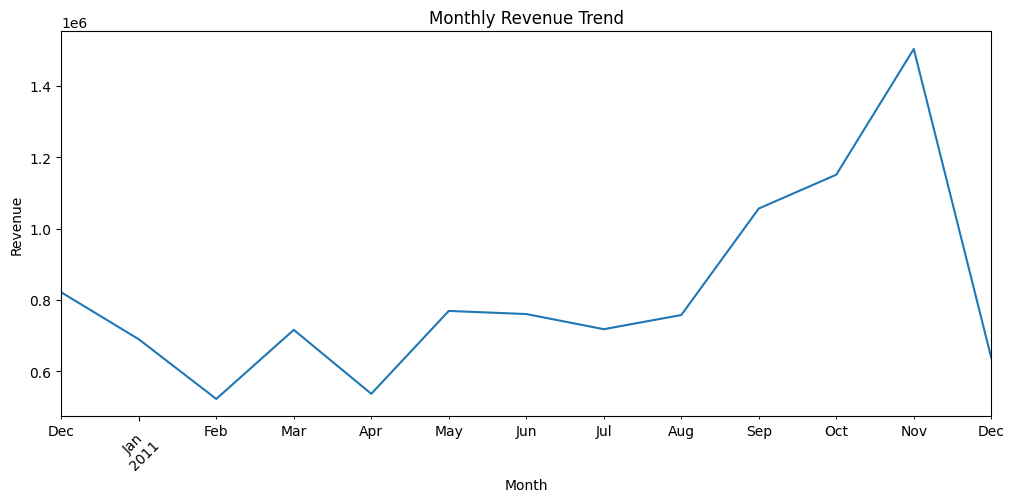

In [237]:
monthly_revenue.plot(
    kind="line",
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [238]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
country_revenue.head(10)

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


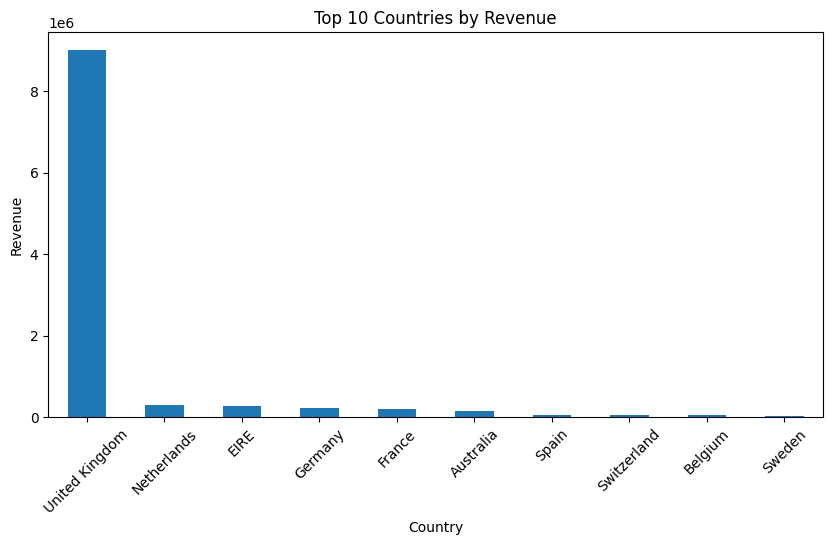

In [239]:
country_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [240]:
product_revenue = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
product_revenue.head(10)

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


In [241]:
product_quantity = (
    sales_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

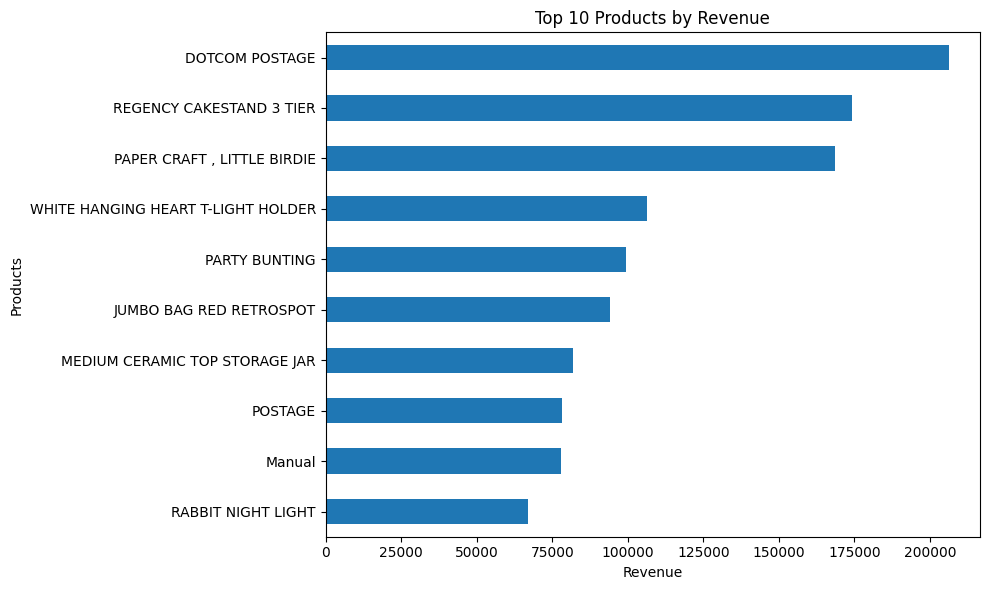

In [242]:
top_products = sales_df.groupby("Description")["Revenue"].sum().nlargest(10)

top_products.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Products")
plt.tight_layout()
plt.show()

In [243]:
# 9. Customer Analysis
customer_summary = (
    customer_sales_df
    .groupby("CustomerID")
    .agg(
        Order_Count=("InvoiceNo", "nunique"),
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

In [244]:
customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Order_Count"]
)

In [245]:
customer_summary.sort_values(
    "Total_Revenue",
    ascending=False
).head(20)

,CustomerID,Order_Count,Total_Revenue,Total_Quantity,Average_Order_Value
1689,14646.0,73,280206.02,196915,3838.438630
4201,18102.0,60,259657.30,64124,4327.621667
3728,17450.0,46,194390.79,69973,4225.886739
3008,16446.0,2,168472.50,80997,84236.250000
1879,14911.0,201,143711.17,80240,714.980945
55,12415.0,21,124914.53,77374,5948.310952
1333,14156.0,55,117210.08,57768,2131.092364
3771,17511.0,31,91062.38,64549,2937.496129
2702,16029.0,63,80850.84,40108,1283.346667
0,12346.0,1,77183.60,74215,77183.600000


In [246]:
customer_sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [247]:
# 10. RFM Analysis
reference_date = customer_sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [248]:
rfm = customer_sales_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

In [249]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [250]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)
rfm[["CustomerID", "Recency", "R_Score"]].head(10)

,CustomerID,Recency,R_Score
0,12346.0,326,1
1,12347.0,2,5
2,12348.0,75,2
3,12349.0,19,4
4,12350.0,310,1
5,12352.0,36,3
6,12353.0,204,1
7,12354.0,232,1
8,12355.0,214,1
9,12356.0,23,4


In [251]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)
rfm[["CustomerID", "Frequency", "F_Score"]].head(10)

,CustomerID,Frequency,F_Score
0,12346.0,1,1
1,12347.0,7,5
2,12348.0,4,4
3,12349.0,1,1
4,12350.0,1,1
5,12352.0,8,5
6,12353.0,1,1
7,12354.0,1,1
8,12355.0,1,1
9,12356.0,3,3


In [252]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)
rfm[["CustomerID", "Monetary", "M_Score"]].head(10)

,CustomerID,Monetary,M_Score
0,12346.0,77183.60,5
1,12347.0,4310.00,5
2,12348.0,1797.24,4
3,12349.0,1757.55,4
4,12350.0,334.40,2
5,12352.0,2506.04,5
6,12353.0,89.00,1
7,12354.0,1079.40,4
8,12355.0,459.40,2
9,12356.0,2811.43,5


In [253]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [254]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112


In [255]:
#Customer Segmentation
def segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["F_Score"] >= 4 and row["M_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 2:
        return "Potential Loyalists"
    elif row["R_Score"] <= 2 and row["M_Score"] >= 3:
        return "At Risk"
    else:
        return "Inactive / Others"

In [256]:
rfm["Segment"] = rfm.apply(segment, axis=1)

In [257]:
rfm["Segment"].value_counts()

,count
Segment,
Inactive / Others,1705
Champions,957
Loyal Customers,693
Potential Loyalists,526
At Risk,457


In [258]:
#Revenue by Segment
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

segment_revenue

,Monetary
Segment,
Champions,5791640.740
Loyal Customers,1298467.951
At Risk,649630.912
Inactive / Others,628216.301
Potential Loyalists,519252.990


In [259]:
#average spending per customer within each segment.
segment_average = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

segment_average

,Monetary
Segment,
Champions,6051.871202
Loyal Customers,1873.691127
At Risk,1421.511842
Potential Loyalists,987.172985
Inactive / Others,368.455309


In [260]:
at_risk = rfm[
    (rfm["R_Score"] <= 2) &
    (rfm["M_Score"] >= 3)
].copy()

at_risk.head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
3,12349.0,19,1,1757.55,4,1,4,414,Inactive / Others
5,12352.0,36,8,2506.04,3,5,5,355,Loyal Customers
9,12356.0,23,3,2811.43,4,3,5,435,Potential Loyalists
10,12357.0,33,1,6207.67,4,1,5,415,Inactive / Others
11,12358.0,2,2,1168.06,5,2,4,524,Potential Loyalists
12,12359.0,58,4,6310.03,3,4,5,345,Loyal Customers
13,12360.0,52,3,2662.06,3,3,5,335,Inactive / Others
15,12362.0,3,10,5226.23,5,5,5,555,Champions


In [261]:
len(at_risk)

2381

In [262]:
at_risk["Monetary"].sum()

np.float64(8038749.402000001)

In [263]:
#Top 10 Customers by Revenue
top_customers = rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)
top_customers[
    ["CustomerID", "Recency", "Frequency", "Monetary", "RFM_Score", "Segment"]
]

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment
1689,14646.0,2,73,280206.02,555,Champions
4201,18102.0,1,60,259657.30,555,Champions
3728,17450.0,8,46,194390.79,555,Champions
3008,16446.0,1,2,168472.50,535,Potential Loyalists
1879,14911.0,1,201,143711.17,555,Champions
55,12415.0,24,21,124914.53,455,Champions
1333,14156.0,10,55,117210.08,555,Champions
3771,17511.0,3,31,91062.38,555,Champions
2702,16029.0,39,63,80850.84,355,Loyal Customers
0,12346.0,326,1,77183.60,115,At Risk


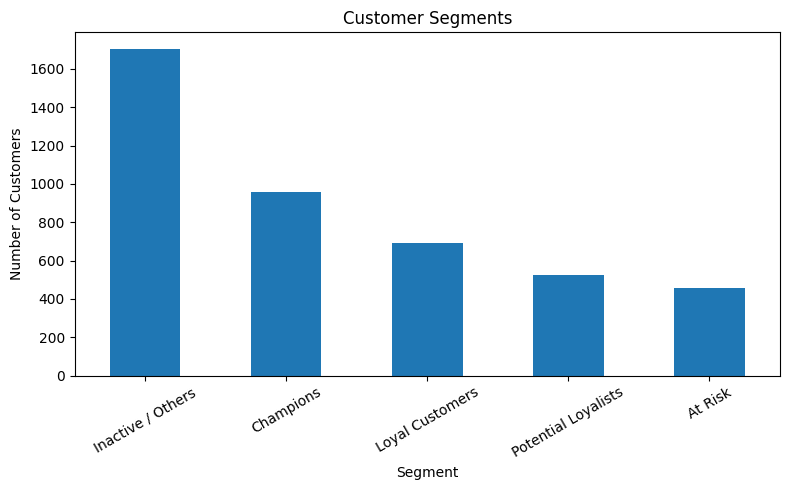

In [264]:
#Customer Segment Visualization
rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

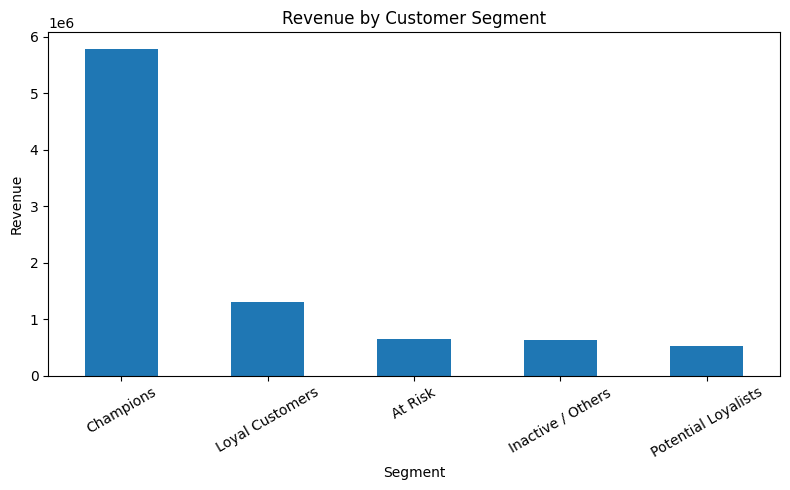

In [265]:
# visualize Revenue by Customer Segment
segment_revenue.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [266]:
rfm.to_csv("customer_rfm_segments.csv", index=False)

In [267]:
from google.colab import files

files.download('customer_rfm_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [268]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CustomerID  4338 non-null   float64 
 1   Recency     4338 non-null   int64   
 2   Frequency   4338 non-null   int64   
 3   Monetary    4338 non-null   float64 
 4   R_Score     4338 non-null   category
 5   F_Score     4338 non-null   category
 6   M_Score     4338 non-null   category
 7   RFM_Score   4338 non-null   object  
 8   Segment     4338 non-null   object  
dtypes: category(3), float64(2), int64(2), object(2)
memory usage: 216.8+ KB


In [269]:
rfm.isnull().sum()

,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0
R_Score,0
F_Score,0
M_Score,0
RFM_Score,0
Segment,0


In [270]:
segment_customers = rfm["Segment"].value_counts()

segment_customers

,count
Segment,
Inactive / Others,1705
Champions,957
Loyal Customers,693
Potential Loyalists,526
At Risk,457


In [271]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,At Risk
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
3,12349.0,19,1,1757.55,4,1,4,414,Inactive / Others
4,12350.0,310,1,334.40,1,1,2,112,Inactive / Others


In [272]:
#Business Insights
total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
total_customers = customer_sales_df["CustomerID"].nunique()
total_products = sales_df["Description"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 10642110.8
Total Orders: 19960
Total Customers: 4338
Total Products: 4026
Average Order Value: 533.17


main Executive Overview KPIs.

In [273]:
best_revenue_segment = segment_revenue.idxmax()
best_revenue_value = segment_revenue.max()

print("Highest Revenue Segment:", best_revenue_segment)
print("Revenue:", round(best_revenue_value, 2))

Highest Revenue Segment: Champions
Revenue: 5791640.74


In [274]:
largest_segment = segment_customers.idxmax()
largest_segment_count = segment_customers.max()

print("Largest Customer Segment:", largest_segment)
print("Number of Customers:", largest_segment_count)

Largest Customer Segment: Inactive / Others
Number of Customers: 1705


**Finding:** Inactive / Others is the largest customer segment, containing 1,705 customers.

**Business meaning:** A substantial portion of the customer base does not currently meet the RFM thresholds for Champions, Loyal Customers, Potential Loyalists, or At Risk.

**Potential action:** Analyze this group further and use targeted re-engagement campaigns where appropriate.

In [275]:
print("Potentially At-Risk Customers:", len(at_risk))
print("Historical Revenue from At-Risk Customers:", round(at_risk["Monetary"].sum(), 2))

Potentially At-Risk Customers: 2381
Historical Revenue from At-Risk Customers: 8038749.4


**Finding:** 2,381 customers are classified as potentially at-risk based on low recency and relatively high monetary scores, representing approximately 8.04 million in historical revenue.

**Business meaning:** This customer group represents a significant historical revenue base that could be considered for targeted retention or win-back activities.

**Recommended action:** Use personalized offers, reminders, and re-engagement campaigns to encourage these customers to return.

**note:**8.04 million is historical revenue, not revenue guaranteed to be recovered. RFM identifies an opportunity; it doesn't predict how much revenue a campaign will recover.

In [276]:
top_product = sales_df.groupby("Description")["Revenue"].sum().idxmax()
top_product_revenue = sales_df.groupby("Description")["Revenue"].sum().max()

print("Top Product by Revenue:", top_product)
print("Revenue:", round(top_product_revenue, 2))

Top Product by Revenue: DOTCOM POSTAGE
Revenue: 206248.77


**Finding: **DOTCOM POSTAGE generated the highest historical revenue among the product descriptions, with revenue of 206,248.77.

**Business meaning:** This item has a significant historical revenue contribution in the dataset and should be examined further to understand the nature of its transactions and its relationship to customer orders.

**Recommended action:** Investigate the transaction pattern behind this item before treating it as a conventional product opportunity, and consider whether it represents postage/service-related charges rather than a physical product.

In [277]:
#final insight table:
insights = pd.DataFrame({
    "Finding": [
        "Largest customer segment",
        "Potentially at-risk customers",
        "Top product by revenue"
    ],

    "Evidence": [
        "Inactive / Others contains 1,705 customers",
        "2,381 potentially at-risk customers represent 8,038,749.40 in historical revenue",
        "DOTCOM POSTAGE generated 206,248.77 in historical revenue"
    ],

    "Business Meaning": [
        "A large portion of customers does not currently meet the criteria for the higher-value or active RFM segments.",
        "A significant historical revenue base is associated with customers showing low recency and relatively high monetary scores.",
        "DOTCOM POSTAGE has the highest historical revenue among the product descriptions."
    ],

    "Recommended Action": [
        "Analyze this group further and develop appropriate re-engagement strategies.",
        "Consider targeted retention and win-back campaigns.",
        "Investigate the nature of this item before treating it as a conventional product opportunity."
    ]
})

insights

,Finding,Evidence,Business Meaning,Recommended Action
0,Largest customer segment,"Inactive / Others contains 1,705 customers",A large portion of customers does not currentl...,Analyze this group further and develop appropr...
1,Potentially at-risk customers,"2,381 potentially at-risk customers represent ...",A significant historical revenue base is assoc...,Consider targeted retention and win-back campa...
2,Top product by revenue,"DOTCOM POSTAGE generated 206,248.77 in histori...",DOTCOM POSTAGE has the highest historical reve...,Investigate the nature of this item before tre...


In [278]:
insights.to_csv("business_insights.csv", index=False)

In [279]:
#Business Recommendations
recommendations = pd.DataFrame({
    "Area": [
        "Customer Retention",
        "Customer Re-engagement",
        "Customer Segmentation",
        "Product Analysis"
    ],

    "Finding": [
        "2,381 customers are potentially at risk based on RFM scores.",
        "Potentially at-risk customers represent 8,038,749.40 in historical revenue.",
        "Inactive / Others is the largest segment with 1,705 customers.",
        "DOTCOM POSTAGE generated 206,248.77 in historical revenue."
    ],

    "Recommendation": [
        "Launch targeted win-back campaigns for potentially at-risk customers.",
        "Prioritize high-value at-risk customers for personalized communication and offers.",
        "Analyze the Inactive / Others group and develop suitable re-engagement strategies.",
        "Investigate DOTCOM POSTAGE transactions to understand whether they represent postage/service charges or conventional product sales."
    ],

    "Business Purpose": [
        "Encourage customers who have not purchased recently to return.",
        "Focus retention resources on customers with meaningful historical value.",
        "Identify opportunities to reactivate inactive customers.",
        "Avoid misinterpreting service-related revenue as ordinary product demand."
    ]
})

recommendations

,Area,Finding,Recommendation,Business Purpose
0,Customer Retention,"2,381 customers are potentially at risk based ...",Launch targeted win-back campaigns for potenti...,Encourage customers who have not purchased rec...
1,Customer Re-engagement,"Potentially at-risk customers represent 8,038,...",Prioritize high-value at-risk customers for pe...,Focus retention resources on customers with me...
2,Customer Segmentation,Inactive / Others is the largest segment with ...,Analyze the Inactive / Others group and develo...,Identify opportunities to reactivate inactive ...
3,Product Analysis,"DOTCOM POSTAGE generated 206,248.77 in histori...",Investigate DOTCOM POSTAGE transactions to und...,Avoid misinterpreting service-related revenue ...


In [280]:
recommendations.to_csv(
    "business_recommendations.csv",
    index=False
)

In [281]:
from google.colab import files

files.download('business_insights.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [282]:
from google.colab import files

files.download('business_recommendations.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [283]:
monthly_revenue = (
    sales_df
    .groupby(sales_df["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].astype(str)

monthly_revenue

,InvoiceDate,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [284]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


In [285]:
top_products = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .nlargest(10)
    .sort_values(ascending=True)
    .reset_index()
)

top_products

,Description,Revenue
0,RABBIT NIGHT LIGHT,66870.03
1,Manual,77752.82
2,POSTAGE,78101.88
3,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
4,JUMBO BAG RED RETROSPOT,94159.81
5,PARTY BUNTING,99445.23
6,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
7,"PAPER CRAFT , LITTLE BIRDIE",168469.60
8,REGENCY CAKESTAND 3 TIER,174156.54
9,DOTCOM POSTAGE,206248.77


In [286]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Customers"]

segment_summary

,Segment,Customers
0,Inactive / Others,1705
1,Champions,957
2,Loyal Customers,693
3,Potential Loyalists,526
4,At Risk,457


In [287]:
segment_revenue_dashboard = (
    rfm
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue_dashboard.columns = ["Segment", "Revenue"]

segment_revenue_dashboard

,Segment,Revenue
0,Champions,5791640.740
1,Loyal Customers,1298467.951
2,At Risk,649630.912
3,Inactive / Others,628216.301
4,Potential Loyalists,519252.990


In [288]:
monthly_revenue.to_csv("monthly_revenue.csv", index=False)

country_revenue.to_csv("country_revenue.csv", index=False)

top_products.to_csv("top_products.csv", index=False)

segment_summary.to_csv("segment_summary.csv", index=False)

segment_revenue_dashboard.to_csv(
    "segment_revenue.csv",
    index=False
)

In [289]:
import os

files = [
    "clean_sales_data.csv",
    "clean_customer_sales_data.csv",
    "customer_rfm_segments.csv"
]

for file in files:
    print(file, os.path.exists(file))

clean_sales_data.csv True
clean_customer_sales_data.csv True
customer_rfm_segments.csv True


In [292]:
import os

print(os.listdir("/content"))

['.config', 'app.py', 'business_insights.csv', 'logs.txt', 'monthly_revenue.csv', 'top_products.csv', 'segment_revenue.csv', 'clean_customer_sales_data.csv', 'business_recommendations.csv', 'segment_summary.csv', 'clean_sales_data.csv', 'customer_rfm_segments.csv', 'country_revenue.csv', 'sample_data']


In [293]:
import os

base = "/content/Ecommerce_Customer_Sales_Intelligence"

folders = [
    "01_Raw_Data",
    "02_Colab_Analysis",
    "03_Clean_Data",
    "04_Visualizations",
    "05_Project_Report",
    "06_Dashboard",
    "07_Final_Files"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [294]:
!find /content/Ecommerce_Customer_Sales_Intelligence -maxdepth 1 -type d

/content/Ecommerce_Customer_Sales_Intelligence
/content/Ecommerce_Customer_Sales_Intelligence/07_Final_Files
/content/Ecommerce_Customer_Sales_Intelligence/05_Project_Report
/content/Ecommerce_Customer_Sales_Intelligence/01_Raw_Data
/content/Ecommerce_Customer_Sales_Intelligence/04_Visualizations
/content/Ecommerce_Customer_Sales_Intelligence/03_Clean_Data
/content/Ecommerce_Customer_Sales_Intelligence/06_Dashboard
/content/Ecommerce_Customer_Sales_Intelligence/02_Colab_Analysis


In [295]:
import shutil
import os

source = "/Online Retail.xlsx"
destination = "/content/Ecommerce_Customer_Sales_Intelligence/01_Raw_Data/Online Retail.xlsx"

if os.path.exists(source):
    shutil.copy(source, destination)
    print("Online Retail.xlsx copied successfully!")
else:
    print("Online Retail.xlsx was not found.")

Online Retail.xlsx copied successfully!


In [296]:
import shutil
import os

files_to_copy = [
    "clean_sales_data.csv",
    "clean_customer_sales_data.csv",
    "customer_rfm_segments.csv"
]

destination = "/content/Ecommerce_Customer_Sales_Intelligence/03_Clean_Data"

for file in files_to_copy:
    if os.path.exists("/content/" + file):
        shutil.copy(
            "/content/" + file,
            os.path.join(destination, file)
        )
        print("Copied:", file)
    else:
        print("NOT FOUND:", file)

Copied: clean_sales_data.csv
Copied: clean_customer_sales_data.csv
Copied: customer_rfm_segments.csv


In [297]:
import matplotlib.pyplot as plt
import os

visual_folder = "/content/Ecommerce_Customer_Sales_Intelligence/04_Visualizations"
os.makedirs(visual_folder, exist_ok=True)

# Monthly Revenue
monthly = sales_df.groupby(
    sales_df["InvoiceDate"].dt.to_period("M")
)["Revenue"].sum()

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12,6))
monthly.plot()
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    visual_folder + "/monthly_revenue.png",
    dpi=200
)
plt.close()


# Top Countries
countries = sales_df.groupby(
    "Country"
)["Revenue"].sum().nlargest(10).sort_values()

plt.figure(figsize=(10,6))
countries.plot(kind="barh")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(
    visual_folder + "/top_countries_revenue.png",
    dpi=200
)
plt.close()


# Top Products
products = sales_df.groupby(
    "Description"
)["Revenue"].sum().nlargest(10).sort_values()

plt.figure(figsize=(10,6))
products.plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(
    visual_folder + "/top_products_revenue.png",
    dpi=200
)
plt.close()


# Customer Segments
segments = rfm["Segment"].value_counts()

plt.figure(figsize=(9,6))
segments.plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(
    visual_folder + "/customer_segments.png",
    dpi=200
)
plt.close()


# Revenue by Segment
segment_revenue = rfm.groupby(
    "Segment"
)["Monetary"].sum().sort_values()

plt.figure(figsize=(9,6))
segment_revenue.plot(kind="barh")
plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(
    visual_folder + "/revenue_by_segment.png",
    dpi=200
)
plt.close()

print("All visualizations saved!")

All visualizations saved!
